# Mini-Project 3 — Lake Victoria Fish Stock & Export Risk Model

**Scenario.** A fish-export cooperative in Jinja wants to know (a) whether its harvesting rate is sustainable and (b) how risky its revenue is. The previous cohort modelled stock with Fibonacci numbers and flagged risk when revenue variance exceeded 50,000. This notebook replaces both with defensible models and explains why the old approach fails.

The logic lives in [`src/fisheries.py`](src/fisheries.py):

| Class | Responsibility | OOP idea |
|---|---|---|
| `HarvestPolicy` → `ClosedSeasonPolicy` | Harvest fraction for a given week; the subclass returns 0 in closed weeks | Inheritance, polymorphism (`rate_at`) |
| `FishStock` | Discrete logistic growth with harvesting; analytic equilibrium and MSY | Composition (*has a* policy), validation |
| `StockTrajectory` | Stock and harvest arrays with derived totals | Frozen dataclass, `__len__` |
| `PriceModel` | Seeded, bounded random walk for price (UGX/kg) | Encapsulated RNG state, `reset()` |
| `RiskAssessor` | `statistics`-based summaries, CV risk classes, VaR, combined ecological + financial rating | Configurable rule object |

### Assumptions
1. **Time step = one week**, and $r$ and $h$ are rates **per week**, as the brief's 52-week simulation implies. $h$ is the fraction of the current stock landed that week.
2. The cooperative's **base-case harvest rate is h = 0.10**, used in Tasks 2–5. Task 6 compares all rates.
3. The price random walk has weekly steps drawn from Normal(0, 400 UGX), about 3 % of the starting price, **reflected** at the 9,000 and 16,000 UGX/kg bounds. Reflection avoids the unrealistic pile-up of probability at the bounds that clipping creates.
4. Stock dynamics are deterministic. All uncertainty comes from price, so the same 1,000 price paths are reused across harvest scenarios (*common random numbers*). Differences between scenarios are then due to the harvest rate, not to sampling noise.
5. All parameters are illustrative. With $K$ = 10,000 t and $r$ = 0.4/week, the implied catch (tens of thousands of tonnes a year) is far larger than any single cooperative lands; the *relative* conclusions are what matter.

In [1]:
import statistics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.fisheries import (
    fibonacci_stock, HarvestPolicy, ClosedSeasonPolicy, FishStock, PriceModel,
    weekly_revenue, RiskAssessor,
)

SEED = 2026
rng = np.random.default_rng(SEED)
pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

R, K, N0, WEEKS = 0.4, 10_000.0, 4_000.0, 52
BASE_H = 0.10
N_PATHS = 1_000
BN = 1e9   # display revenue in UGX billions

## Task 1 — The Fibonacci baseline

In [2]:
fib = fibonacci_stock(15)
print("Fibonacci 'stock':", fib)
print("Successive ratios:", np.round(np.array(fib[1:]) / np.array(fib[:-1]), 3))

Fibonacci 'stock': [1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610]
Successive ratios: [1.    2.    1.5   1.667 1.6   1.625 1.615 1.619 1.618 1.618 1.618 1.618
 1.618 1.618]


**Why unbounded Fibonacci growth is biologically unrealistic.** Each term is the sum of the previous two, so the "stock" grows geometrically forever: the ratio settles at φ ≈ 1.618, i.e. ~62 % growth per step, regardless of how many fish are already in the lake. Real populations are limited by food, oxygen, breeding habitat and predation. Growth *slows* as density rises and stops at a carrying capacity, which the Fibonacci model cannot represent. The model also contains no mortality, no harvesting and no parameter that can be estimated from data, so it cannot answer the cooperative's actual question: how much can be taken without depleting the stock? Continued for a year of weekly steps, it would predict more fish than the lake could physically hold.

## Task 2 — `FishStock`: logistic growth with harvesting

In [3]:
stock = FishStock(r=R, K=K, n0=N0, policy=BASE_H)
traj = stock.simulate(WEEKS)
print(stock)
print(f"Week 0: {traj.stock[0]:,.0f} t -> week 52: {traj.final_stock:,.0f} t")
print(f"Total landed in the year: {traj.total_harvest:,.0f} t (mean {traj.total_harvest / WEEKS:,.0f} t/week)")

# Hand check of the first step: 4000 + 0.4*4000*(1 - 0.4) - 0.1*4000
print(f"Week 1 by hand: {4000 + 0.4 * 4000 * 0.6 - 0.1 * 4000:,.0f} t | simulated: {traj.stock[1]:,.0f} t")
print(f"Analytic equilibrium K(1 - h/r) = {stock.equilibrium():,.0f} t")

FishStock(r=0.4, K=10,000, n0=4,000, policy=HarvestPolicy(rate=0.1))
Week 0: 4,000 t -> week 52: 7,500 t
Total landed in the year: 37,363 t (mean 719 t/week)
Week 1 by hand: 4,560 t | simulated: 4,560 t
Analytic equilibrium K(1 - h/r) = 7,500 t


Setting $N_{t+1} = N_t$ gives the equilibrium $N^* = K(1 - h/r)$ (for $h < r$), with long-run yield $Y(h) = hN^* = hK(1-h/r)$. Maximising $Y$ over $h$ gives $h_{MSY} = r/2 = 0.2$ and $\text{MSY} = rK/4 = 1{,}000$ t/week at $N = K/2$. With $h = 0.10$ the stock rises from 4,000 t to its equilibrium of 7,500 t within a few weeks. The simulation lands exactly on the analytic value, which is a useful correctness check.

## Task 3 — `PriceModel` and weekly revenue

In [4]:
price_model = PriceModel(start=12_000, lower=9_000, upper=16_000, step_sd=400, seed=SEED)
print(price_model)
price_path = price_model.simulate(WEEKS, n_paths=1)[0]
revenue = weekly_revenue(traj.harvest, price_path)       # harvest t x 1000 kg/t x UGX/kg
print(f"Price range this year: {price_path.min():,.0f} - {price_path.max():,.0f} UGX/kg")
print(f"Week 1 revenue by hand: {traj.harvest[0]:,.0f} t x 1,000 x {price_path[0]:,.0f} = UGX {traj.harvest[0] * 1000 * price_path[0]:,.0f}")
print(f"Annual revenue on this path: UGX {revenue.sum() / BN:,.1f} billion")

PriceModel(start=12,000, band=[9,000, 16,000], step_sd=400, boundary='reflect', seed=2026)
Price range this year: 11,020 - 15,694 UGX/kg
Week 1 revenue by hand: 400 t x 1,000 x 12,000 = UGX 4,800,000,000
Annual revenue on this path: UGX 460.4 billion


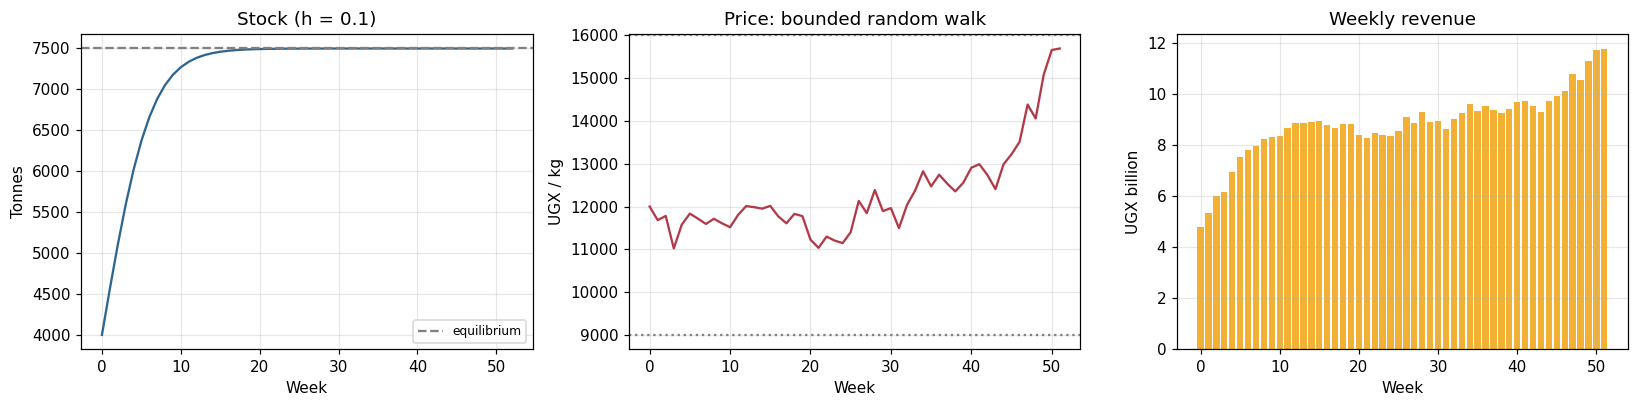

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
axes[0].plot(traj.stock, color="#2F6690"); axes[0].axhline(stock.equilibrium(), ls="--", color="grey", label="equilibrium")
axes[0].set(title=f"Stock (h = {BASE_H})", xlabel="Week", ylabel="Tonnes"); axes[0].legend(fontsize=8)
axes[1].plot(price_path, color="#B23A48")
for b in (9_000, 16_000): axes[1].axhline(b, ls=":", color="grey")
axes[1].set(title="Price: bounded random walk", xlabel="Week", ylabel="UGX / kg")
axes[2].bar(range(WEEKS), revenue / BN, color="#F2B134")
axes[2].set(title="Weekly revenue", xlabel="Week", ylabel="UGX billion")
fig.tight_layout(); plt.show()

## Task 4 — Descriptive statistics of revenue, and why a variance threshold of 50,000 is meaningless

In [6]:
desc = RiskAssessor.describe(revenue)
table = pd.DataFrame({
    "value": [desc["mean"], desc["median"], desc["variance"], desc["std"], desc["cv"]],
    "units": ["UGX", "UGX", "UGX²", "UGX", "none (ratio)"],
}, index=["mean", "median", "variance", "std", "CV"])
table["value"] = table["value"].map(lambda v: f"{v:,.4g}")
table

,value,units
mean,8.853e+09,UGX
median,8.893e+09,UGX
variance,1.793e+18,UGX²
std,1.339e+09,UGX
CV,0.1513,none (ratio)


In [7]:
units = {"UGX": 1, "thousand UGX": 1e3, "million UGX": 1e6, "billion UGX": 1e9}
rows = []
for label, scale in units.items():
    d = RiskAssessor.describe(revenue / scale)
    rows.append({"revenue measured in": label, "variance": d["variance"], "variance > 50,000 ?": d["variance"] > 50_000,
                 "CV": d["cv"]})
pd.DataFrame(rows).set_index("revenue measured in").style.format({"variance": "{:,.4g}", "CV": "{:.4f}"})

,variance,"variance > 50,000 ?",CV
revenue measured in,,,
UGX,1.793e+18,True,0.1513
thousand UGX,1.793e+12,True,0.1513
million UGX,1.793e+06,True,0.1513
billion UGX,1.793,False,0.1513


**The variance is in UGX² (shillings squared)**, a unit with no business meaning, and its size depends entirely on the unit chosen for revenue. The *same* revenue stream has a variance of about $1.8 \times 10^{18}$ UGX², $1.8 \times 10^{12}$ in thousands of UGX², $1.8 \times 10^{6}$ in millions and $1.8$ in billions. The 50,000 rule therefore flags the cooperative as "risky" in three of the four units and "safe" in the fourth, although nothing about its business has changed. At realistic revenue levels any threshold in UGX² is crossed trivially, so the rule classifies everything as risky.

Variance also grows with the *square* of scale: a cooperative twice as big, with identical relative fluctuations, has four times the variance. The **coefficient of variation** $CV = s/\bar{x}$ is dimensionless and scale-free. It is the same (0.15 here) in every unit and says "a typical week deviates about 15 % from the average week". That is the quantity a risk rule should use.

One caveat: this within-year CV of *weekly* revenue mixes genuine price risk with the predictable rise in landings as the stock builds up. For the *annual* risk question, the next task uses the CV across many simulated years instead.

## Task 5 — `RiskAssessor`: a justified CV rule and Monte Carlo Value-at-Risk

**Rule.** Classify by the CV of **annual revenue across simulated price paths**: *Low* if CV < 10 %, *Moderate* if 10–20 %, and *High* if ≥ 20 %.

**Justification.** For a roughly normal outcome, the worst year in twenty lies about $1.645 \times CV$ below the mean. At CV = 10 % that is a 16 % shortfall, which a cooperative with ordinary operating margins and some cash reserves can absorb. At CV = 20 % it is a 33 % shortfall, which would typically wipe out a year's margin and threaten loan repayments. The thresholds therefore map directly onto how bad a 1-in-20 year is. The Monte Carlo VaR below checks this approximation without assuming normality.

**VaR definition.** $\text{VaR}_{5\%}$ = mean annual revenue − 5th percentile of annual revenue: the shortfall below expectations that is exceeded in only 5 % of years.

In [8]:
assessor = RiskAssessor(low=0.10, high=0.20, alpha=0.05)
mc_prices = PriceModel(seed=SEED).simulate(WEEKS, n_paths=N_PATHS)      # (1000, 52), reused below
annual = weekly_revenue(traj.harvest, mc_prices).sum(axis=1)            # one annual total per path
report = assessor.assess(annual, stock)
ann = RiskAssessor.describe(annual)

print(f"Monte Carlo: {N_PATHS:,} price paths, harvest rate h = {BASE_H}")
print(f"Mean annual revenue      : UGX {report.mean / BN:,.1f} bn  (median {ann['median'] / BN:,.1f} bn)")
print(f"Std / CV                 : UGX {ann['std'] / BN:,.1f} bn / {report.cv:.1%}")
print(f"5th percentile (VaR level): UGX {report.var_level / BN:,.1f} bn")
print(f"5% VaR (shortfall)       : UGX {report.value_at_risk / BN:,.1f} bn = {report.value_at_risk / report.mean:.1%} of the mean")
print(f"Normal approximation     : 1.645 x CV = {1.645 * report.cv:.1%}")
print(f"Financial class: {report.financial_class} | stock status: {report.stock_status} | overall: {report.overall_class}")

Monte Carlo: 1,000 price paths, harvest rate h = 0.1
Mean annual revenue      : UGX 451.1 bn  (median 447.3 bn)
Std / CV                 : UGX 49.4 bn / 10.9%
5th percentile (VaR level): UGX 379.0 bn
5% VaR (shortfall)       : UGX 72.2 bn = 16.0% of the mean
Normal approximation     : 1.645 x CV = 18.0%
Financial class: Moderate | stock status: Sustainable | overall: Moderate


The simulated VaR (≈ 16 % of mean revenue) is close to the normal approximation (≈ 18 %), which supports using CV as the classifier. It is slightly smaller because the reflecting price floor caps the worst outcomes. Revenue risk at h = 0.10 is **Moderate**: in one year out of twenty, the cooperative should expect to earn at least about UGX 72 billion less than planned.

## Task 6 — Scenario analysis across harvest rates vs MSY

In [9]:
rates = [0.05, 0.10, 0.20, 0.30]
extra = [0.45]                      # beyond r: illustrates collapse (not in the brief)
rows, trajectories, annual_by_h = [], {}, {}
for h in rates + extra:
    s = FishStock(r=R, K=K, n0=N0, policy=h)
    t = s.simulate(WEEKS)
    a = weekly_revenue(t.harvest, mc_prices).sum(axis=1)      # same price paths for every h
    rep = assessor.assess(a, s)
    trajectories[h], annual_by_h[h] = t, a
    rows.append({
        "h": h, "final stock (t)": t.final_stock, "equilibrium N* (t)": s.equilibrium(),
        "harvest (t/yr)": t.total_harvest, "mean t/week": t.total_harvest / WEEKS,
        "% of MSY": 100 * t.total_harvest / WEEKS / s.msy,
        "mean revenue (UGX bn)": rep.mean / BN, "CV": rep.cv, "5% VaR (UGX bn)": rep.value_at_risk / BN,
        "financial risk": rep.financial_class, "stock status": rep.stock_status, "overall risk": rep.overall_class,
    })
scen = pd.DataFrame(rows).set_index("h")
print(f"MSY = rK/4 = {FishStock().msy:,.0f} t/week ({FishStock().msy * WEEKS:,.0f} t/yr) at h_MSY = r/2 = {FishStock().h_msy}")
scen

MSY = rK/4 = 1,000 t/week (52,000 t/yr) at h_MSY = r/2 = 0.2


,final stock (t),equilibrium N* (t),harvest (t/yr),mean t/week,% of MSY,mean revenue (UGX bn),CV,5% VaR (UGX bn),financial risk,stock status,overall risk
h,,,,,,,,,,,
0.05,"8,750.00","8,750.00","21,714.61",417.59,41.76,262.21,0.11,42.08,Moderate,Sustainable,Moderate
0.10,"7,500.00","7,500.00","37,362.51",718.51,71.85,451.14,0.11,72.16,Moderate,Sustainable,Moderate
0.20,"4,999.99","5,000.00","50,871.71",978.30,97.83,614.18,0.11,96.05,Moderate,Sustainable,Moderate
0.30,"2,503.72","2,500.00","42,461.02",816.56,81.66,512.33,0.10,75.49,Moderate,Overfished,Moderate
0.45,64.47,0.00,"15,030.09",289.04,28.90,180.55,0.06,18.07,Low,Collapsing,High


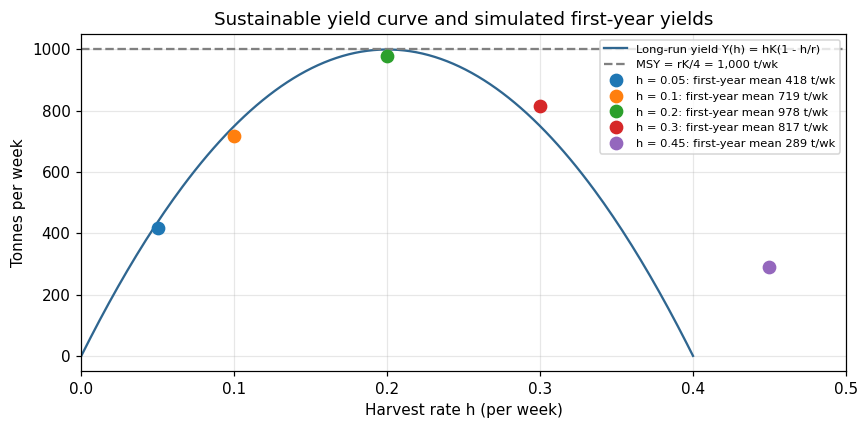

In [10]:
h_grid = np.linspace(0, R, 200)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(h_grid, [FishStock().sustainable_yield(h) for h in h_grid], color="#2F6690", label="Long-run yield Y(h) = hK(1 - h/r)")
ax.axhline(FishStock().msy, ls="--", color="grey", label="MSY = rK/4 = 1,000 t/wk")
for h in rates + extra:
    ax.plot(h, trajectories[h].total_harvest / WEEKS, "o", ms=8, label=f"h = {h}: first-year mean {trajectories[h].total_harvest / WEEKS:,.0f} t/wk")
ax.set(xlabel="Harvest rate h (per week)", ylabel="Tonnes per week", title="Sustainable yield curve and simulated first-year yields",
       xlim=(0, 0.5))
ax.legend(fontsize=7.5, loc="upper right"); fig.tight_layout(); fig.savefig("figures/p3_yield_curve.png", bbox_inches="tight")
plt.show()

**Reading the scenarios against MSY.**

* **h = 0.20 = r/2 is the MSY rate.** The stock settles at $K/2$ = 5,000 t and lands about 980 t/week, 98 % of the theoretical 1,000 (the shortfall is the first few weeks, while the stock climbs from 4,000 t). It also earns the highest revenue.
* **h = 0.05 and 0.10 are under-fishing.** They leave a large, safe stock (8,750 t and 7,500 t) but forgo 25–55 % of the attainable yield.
* **h = 0.30 is over-fishing.** Although $h < r$, so the stock does not collapse, it is pushed to 2,500 t, *half* the MSY biomass. It lands *less* than h = 0.20 while working the fishery harder, which is the classic "growth overfishing" trap. It also has the least margin for error: an environmental shock would have much larger consequences at this stock level.
* **h = 0.45 (> r, added for illustration)** collapses the stock to near zero within the year.

**The CV class is almost the same for every sustainable rate** (≈ 10–11 %, Moderate). Price risk is multiplicative, so the harvest rate changes the *level* of revenue, not its relative volatility. Worse, the collapsing h = 0.45 scenario has the *lowest* CV (≈ 6 %, "Low"), because most of its revenue is earned in the first weeks, before prices have drifted. A purely financial rule would rate the most destructive policy as the safest. That is why `RiskAssessor` takes the **higher** of the financial class and an ecological floor (Moderate if $h > r/2$, High if $h \ge r$).

## Task 7 — (a) Stock trajectories and (b) simulated annual revenue with VaR

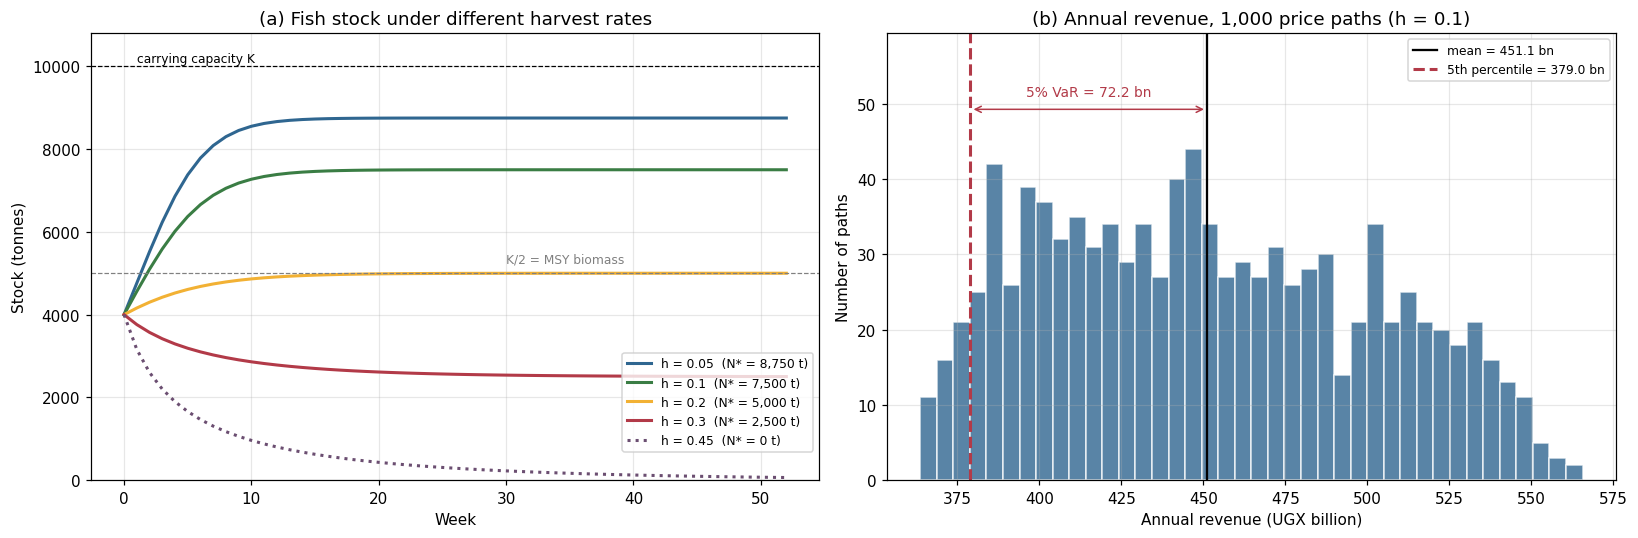

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
colors = ["#2F6690", "#3A7D44", "#F2B134", "#B23A48", "#6B4E71"]
for c, h in zip(colors, rates + extra):
    s = FishStock(policy=h)
    ls = ":" if h in extra else "-"
    ax.plot(trajectories[h].stock, color=c, ls=ls, lw=2, label=f"h = {h}  (N* = {s.equilibrium():,.0f} t)")
ax.axhline(K, color="black", lw=0.8, ls="--"); ax.text(1, K * 1.01, "carrying capacity K", fontsize=8)
ax.axhline(K / 2, color="grey", lw=0.8, ls="--"); ax.text(30, K / 2 + 250, "K/2 = MSY biomass", fontsize=8, color="grey")
ax.set(title="(a) Fish stock under different harvest rates", xlabel="Week", ylabel="Stock (tonnes)", ylim=(0, 10_800))
ax.legend(fontsize=8, loc="lower right", bbox_to_anchor=(1, 0.05))

ax = axes[1]
a = annual_by_h[BASE_H] / BN
counts, _, _ = ax.hist(a, bins=40, color="#2F6690", alpha=0.8, edgecolor="white")
ax.set_ylim(0, counts.max() * 1.35)
ax.axvline(a.mean(), color="black", lw=1.5, label=f"mean = {a.mean():,.1f} bn")
ax.axvline(report.var_level / BN, color="#B23A48", lw=2, ls="--", label=f"5th percentile = {report.var_level / BN:,.1f} bn")
ax.annotate("", xy=(report.var_level / BN, counts.max() * 1.12), xytext=(a.mean(), counts.max() * 1.12),
            arrowprops=dict(arrowstyle="<->", color="#B23A48"))
ax.text((a.mean() + report.var_level / BN) / 2, counts.max() * 1.16, f"5% VaR = {report.value_at_risk / BN:,.1f} bn",
        ha="center", color="#B23A48", fontsize=9)
ax.set(title=f"(b) Annual revenue, {N_PATHS:,} price paths (h = {BASE_H})", xlabel="Annual revenue (UGX billion)", ylabel="Number of paths")
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout(); fig.savefig("figures/p3_stock_and_var.png", bbox_inches="tight")
plt.show()

## Extension — An 8-week closed season over 5 years

`ClosedSeasonPolicy` sets $h = 0$ for weeks 14–21 of every year (roughly April–May; the timing is my assumption, standing in for a breeding-season closure). Because it is a `HarvestPolicy` subclass, `FishStock` uses it unchanged. I compare 5 years (260 weeks) with and without the closure at each harvest rate, on the same 1,000 five-year price paths.

In [12]:
YEARS5 = 5 * WEEKS
prices5 = PriceModel(seed=SEED + 1).simulate(YEARS5, n_paths=N_PATHS)
rows = []
for h in rates + extra:
    open_t = FishStock(policy=h).simulate(YEARS5)
    closed_t = FishStock(policy=ClosedSeasonPolicy(h)).simulate(YEARS5)
    rev_open = weekly_revenue(open_t.harvest, prices5).sum(axis=1)
    rev_closed = weekly_revenue(closed_t.harvest, prices5).sum(axis=1)
    rows.append({
        "h": h,
        "5-yr catch, open (t)": open_t.total_harvest, "5-yr catch, closed (t)": closed_t.total_harvest,
        "5-yr revenue, open (UGX bn)": rev_open.mean() / BN, "5-yr revenue, closed (UGX bn)": rev_closed.mean() / BN,
        "change (%)": 100 * (rev_closed.mean() / rev_open.mean() - 1),
        "paths where closure pays (%)": 100 * np.mean(rev_closed > rev_open),
        "min stock, open (t)": open_t.stock[WEEKS:].min(), "min stock, closed (t)": closed_t.stock[WEEKS:].min(),
    })
closed_tbl = pd.DataFrame(rows).set_index("h")
closed_tbl

,"5-yr catch, open (t)","5-yr catch, closed (t)","5-yr revenue, open (UGX bn)","5-yr revenue, closed (UGX bn)",change (%),paths where closure pays (%),"min stock, open (t)","min stock, closed (t)"
h,,,,,,,,
0.05,"112,714.61","96,025.73","1,394.09","1,187.95",-14.79,0.00,"8,750.00","8,750.00"
0.10,"193,362.51","166,791.47","2,391.51","2,063.36",-13.72,0.00,"7,500.00","7,500.00"
0.20,"258,871.70","234,746.97","3,201.36","2,903.76",-9.30,0.00,"4,999.99","5,000.11"
0.30,"198,472.16","212,732.22","2,453.02","2,630.64",7.24,100.00,"2,500.00","2,515.13"
0.45,"15,595.46","51,423.78",188.23,630.55,235.00,100.00,0.00,52.48


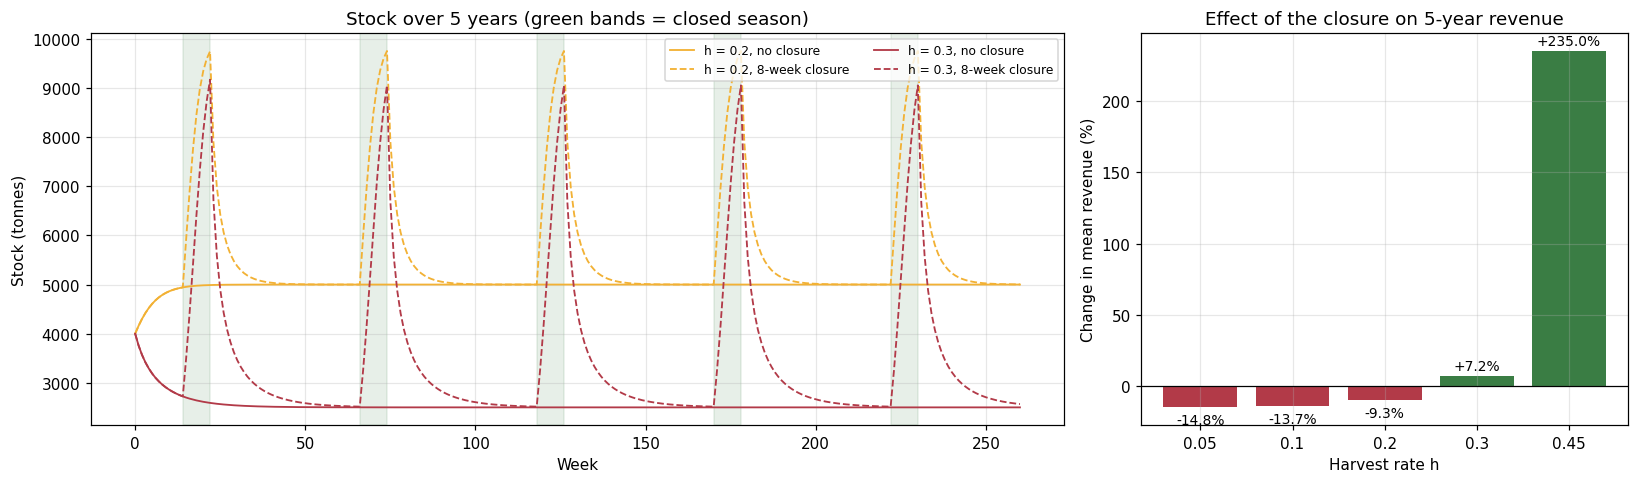

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [2, 1]})
ax = axes[0]
for c, h in zip(["#F2B134", "#B23A48"], [0.20, 0.30]):
    ax.plot(FishStock(policy=h).simulate(YEARS5).stock, color=c, lw=1.2, label=f"h = {h}, no closure")
    ax.plot(FishStock(policy=ClosedSeasonPolicy(h)).simulate(YEARS5).stock, color=c, lw=1.2, ls="--", label=f"h = {h}, 8-week closure")
for y in range(5):
    ax.axvspan(y * WEEKS + 14, y * WEEKS + 22, color="#3A7D44", alpha=0.12)
ax.set(title="Stock over 5 years (green bands = closed season)", xlabel="Week", ylabel="Stock (tonnes)")
ax.legend(fontsize=8, ncol=2)
ax = axes[1]
chg = closed_tbl["change (%)"]
ax.bar([str(h) for h in chg.index], chg, color=["#B23A48" if v < 0 else "#3A7D44" for v in chg])
for i, v in enumerate(chg):
    ax.text(i, v + (4 if v >= 0 else -12), f"{v:+.1f}%", ha="center", fontsize=9)
ax.axhline(0, color="black", lw=0.8)
ax.set(title="Effect of the closure on 5-year revenue", xlabel="Harvest rate h", ylabel="Change in mean revenue (%)")
fig.tight_layout(); fig.savefig("figures/p3_closed_season.png", bbox_inches="tight")
plt.show()

**The closure's value depends on which side of MSY the fishery sits.**

* **At or below the MSY rate (h ≤ 0.20)** the closure *loses* 9–15 % of 5-year revenue in every price path. The stock is already at or above the MSY biomass, so the rebuilt fish are worth less than the catch forgone.
* **Above it (h = 0.30)** the closure *raises* 5-year revenue by about 7 %, in 100 % of paths. The 8-week rest cuts the effective annual rate from 0.30 to about 0.25, closer to $r/2$, and the larger stock more than repays the lost weeks.
* **For the collapsing rate (h = 0.45)** it more than triples 5-year revenue, but does not stop the decline: the stock still ends near zero.

A closed season is therefore a **correction for over-fishing, not a free improvement**. Lowering $h$ to 0.20 would earn more than any closure, but closures are much easier to enforce on a lake than weekly catch shares, so they are a practical second-best.

## Findings & Limitations

**Findings.** Replacing Fibonacci growth with a logistic model turns the cooperative's question into one with a clear answer. The sustainable yield $hK(1-h/r)$ peaks at $h = r/2 = 0.20$ (MSY = 1,000 t/week), and the simulated h = 0.20 scenario lands 98 % of that in its first year while holding the stock at $K/2$. The base case (h = 0.10) is safe but forgoes about a quarter of the attainable catch. h = 0.30 catches *less* than h = 0.20 while halving the stock. On revenue risk, a variance threshold is meaningless because variance carries units of UGX², and the same data pass or fail the 50,000 rule depending on whether revenue is recorded in shillings or billions. CV is scale-free. Across 1,000 price paths it is ≈ 10–11 % for every sustainable rate, with a 5 % VaR of about 16 % of expected annual revenue. The most important result is that financial and ecological risk can point in *opposite* directions: the collapsing h = 0.45 policy has the lowest CV. Any risk rule must therefore include stock status. An 8-week closed season helps only when fishing beyond MSY (+7 % at h = 0.30) and costs 9–15 % otherwise.

**Limitations.** Parameters are illustrative, and $r = 0.4$ per week is far higher than realistic growth rates for Nile perch or tilapia. The stock is deterministic, with no environmental shocks, recruitment variability, age structure or illegal fishing. Price is independent of catch (no demand response), and the random-walk volatility is assumed, not estimated. Costs are ignored, so revenue is not profit. Lower harvest rates may also require less fishing effort. Real use would require fitting $r$ and $K$ to catch-per-unit-effort data from Uganda's fisheries authorities.